# 06. EDA del corpus enriquecido con DBC

Este notebook documenta el cambio entre el corpus base y el corpus enriquecido con Documento Base de Contratacion (DBC). Su objetivo no es repetir el EDA tabular del proyecto, sino generar evidencia para la monografia sobre cobertura y enriquecimiento textual.

## Objetivos

- medir cobertura real del corpus enriquecido
- comparar longitud de `texto_rag` vs `texto_rag_enriched`
- analizar crecimiento textual por tipo de contratacion y modalidad
- exportar figuras listas para posible uso en LaTeX
- exportar una muestra de casos comparativos para anexo o tablas


In [12]:
from __future__ import annotations

import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.config import FIGURES_DIR, PRIMARY_RAG_PATH, TABLES_DIR

CURATED_ENRICHED_PATH = ROOT / "data" / "processed" / "curated" / "curated_corpus_enriched.parquet"
EXAMPLES_PATH = TABLES_DIR / "enriched_text_examples.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")

print("ROOT:", ROOT)
print("BASE_PATH:", PRIMARY_RAG_PATH)
print("ENRICHED_PATH:", CURATED_ENRICHED_PATH)
print("FIGURES_DIR:", FIGURES_DIR)
print("TABLES_DIR:", TABLES_DIR)


ROOT: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03
BASE_PATH: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/data/rag/sicoes_convocatorias_rag.parquet
ENRICHED_PATH: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/data/processed/curated/curated_corpus_enriched.parquet
FIGURES_DIR: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures
TABLES_DIR: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/tables


## 1. Cargar corpus base y enriquecido


In [13]:
base_df = pd.read_parquet(PRIMARY_RAG_PATH)
enriched_df = pd.read_parquet(CURATED_ENRICHED_PATH)

print("Filas base:", len(base_df))
print("Filas enriquecidas:", len(enriched_df))
print("Columnas enriquecidas relevantes:")
print([
    col
    for col in [
        "cuce",
        "texto_rag",
        "texto_rag_enriched",
        "has_dbc",
        "dbc_text",
        "tipo_contratacion",
        "modalidad",
    ]
    if col in enriched_df.columns
])


Filas base: 1418
Filas enriquecidas: 1418
Columnas enriquecidas relevantes:
['cuce', 'texto_rag', 'texto_rag_enriched', 'has_dbc', 'dbc_text', 'tipo_contratacion', 'modalidad']


## 2. Preparar dataset analitico


In [14]:
analysis_df = enriched_df.copy()
analysis_df["texto_rag"] = analysis_df["texto_rag"].fillna("").astype(str)
analysis_df["texto_rag_enriched"] = analysis_df["texto_rag_enriched"].fillna("").astype(str)
analysis_df["has_dbc"] = analysis_df.get("has_dbc", False).fillna(False).astype(bool)

analysis_df["base_chars"] = analysis_df["texto_rag"].str.len()
analysis_df["enriched_chars"] = analysis_df["texto_rag_enriched"].str.len()
analysis_df["char_growth_abs"] = analysis_df["enriched_chars"] - analysis_df["base_chars"]
analysis_df["char_growth_pct"] = (
    analysis_df["char_growth_abs"]
    .div(analysis_df["base_chars"].replace(0, pd.NA))
    .mul(100)
)
analysis_df["base_words"] = analysis_df["texto_rag"].str.split().str.len()
analysis_df["enriched_words"] = analysis_df["texto_rag_enriched"].str.split().str.len()
analysis_df["word_growth_abs"] = analysis_df["enriched_words"] - analysis_df["base_words"]

print("Registros con DBC:", int(analysis_df["has_dbc"].sum()))
print("Registros sin DBC:", int((~analysis_df["has_dbc"]).sum()))
display(
    analysis_df[[
        "cuce",
        "tipo_contratacion",
        "modalidad",
        "has_dbc",
        "base_chars",
        "enriched_chars",
        "char_growth_abs",
    ]].head(10)
)


Registros con DBC: 1000
Registros sin DBC: 418


,cuce,tipo_contratacion,modalidad,has_dbc,base_chars,enriched_chars,char_growth_abs
0,26-1803-00-1669918-1-1,Bienes,CNC,False,454,937,483
1,26-1101-00-1668944-1-1,Bienes,CM,False,524,987,463
2,26-1119-00-1669680-1-1,Bienes,ANPP,False,411,784,373
3,26-1101-00-1669911-1-1,Bienes,CM,False,485,909,424
4,26-0020-21-1664086-2-1,Bienes,ANPP,False,437,836,399
5,26-0902-21-1669906-1-1,Bienes,ANPP,False,372,706,334
6,26-1101-00-1669907-1-1,Bienes,CM,False,491,921,430
7,26-1101-00-1669903-1-1,Bienes,CM,False,493,925,432
8,26-0902-21-1669902-1-1,Bienes,ANPP,False,369,700,331
9,26-0902-21-1669900-1-1,Bienes,ANPP,False,370,702,332


## 3. Resumen general para monografia


In [15]:
coverage_summary = pd.DataFrame(
    [
        {
            "metric": "total_registros",
            "value": len(analysis_df),
        },
        {
            "metric": "registros_con_dbc",
            "value": int(analysis_df["has_dbc"].sum()),
        },
        {
            "metric": "registros_sin_dbc",
            "value": int((~analysis_df["has_dbc"]).sum()),
        },
        {
            "metric": "cobertura_dbc_pct",
            "value": round(float(analysis_df["has_dbc"].mean() * 100), 2),
        },
        {
            "metric": "media_chars_base",
            "value": round(float(analysis_df["base_chars"].mean()), 2),
        },
        {
            "metric": "media_chars_enriched",
            "value": round(float(analysis_df["enriched_chars"].mean()), 2),
        },
        {
            "metric": "media_crecimiento_chars_abs",
            "value": round(float(analysis_df["char_growth_abs"].mean()), 2),
        },
        {
            "metric": "mediana_crecimiento_chars_abs",
            "value": round(float(analysis_df["char_growth_abs"].median()), 2),
        },
    ]
)

display(coverage_summary)


,metric,value
0,total_registros,1418.00
1,registros_con_dbc,1000.00
2,registros_sin_dbc,418.00
3,cobertura_dbc_pct,70.52
4,media_chars_base,422.30
5,media_chars_enriched,18340.68
6,media_crecimiento_chars_abs,17918.38
7,mediana_crecimiento_chars_abs,25498.00


## 4. Figura: cobertura del corpus enriquecido


/tmp/ipykernel_129136/3457777755.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coverage_plot_df, x="grupo", y="total", palette=["#2d6a4f", "#b7c9b3"], ax=ax)


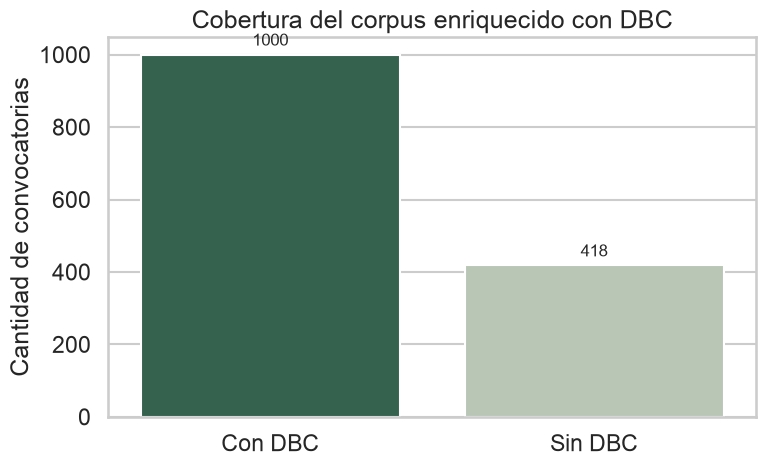

Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_enriched_coverage.png


In [16]:
coverage_plot_df = pd.DataFrame(
    {
        "grupo": ["Con DBC", "Sin DBC"],
        "total": [int(analysis_df["has_dbc"].sum()), int((~analysis_df["has_dbc"]).sum())],
    }
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=coverage_plot_df, x="grupo", y="total", palette=["#2d6a4f", "#b7c9b3"], ax=ax)
ax.set_title("Cobertura del corpus enriquecido con DBC")
ax.set_xlabel("")
ax.set_ylabel("Cantidad de convocatorias")
for patch in ax.patches:
    ax.annotate(
        f"{int(patch.get_height())}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=12,
        xytext=(0, 4),
        textcoords="offset points",
    )
fig.tight_layout()
coverage_fig_path = FIGURES_DIR / "eda_enriched_coverage.png"
fig.savefig(coverage_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Figura guardada en:", coverage_fig_path)


## 5. Figura: longitud de texto base vs enriquecido


/tmp/ipykernel_129136/2554008659.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=length_plot_df, x="corpus", y="chars", palette=["#9fb3c8", "#bc6c25"], ax=ax)


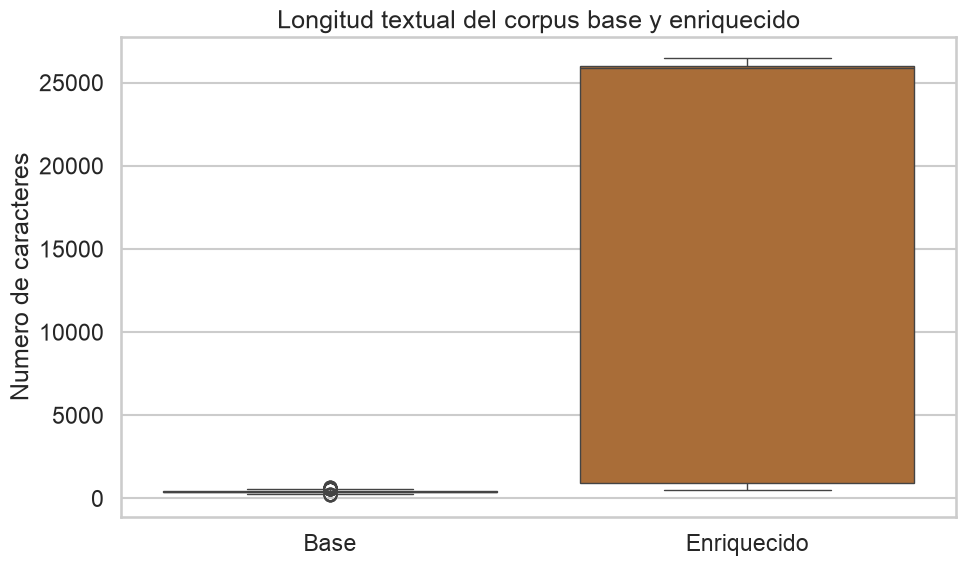

Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_enriched_length_boxplot.png


In [17]:
length_plot_df = analysis_df[["base_chars", "enriched_chars"]].rename(
    columns={"base_chars": "Base", "enriched_chars": "Enriquecido"}
).melt(var_name="corpus", value_name="chars")

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=length_plot_df, x="corpus", y="chars", palette=["#9fb3c8", "#bc6c25"], ax=ax)
ax.set_title("Longitud textual del corpus base y enriquecido")
ax.set_xlabel("")
ax.set_ylabel("Numero de caracteres")
fig.tight_layout()
length_fig_path = FIGURES_DIR / "eda_enriched_length_boxplot.png"
fig.savefig(length_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Figura guardada en:", length_fig_path)


## 6. Figura: distribucion del crecimiento textual


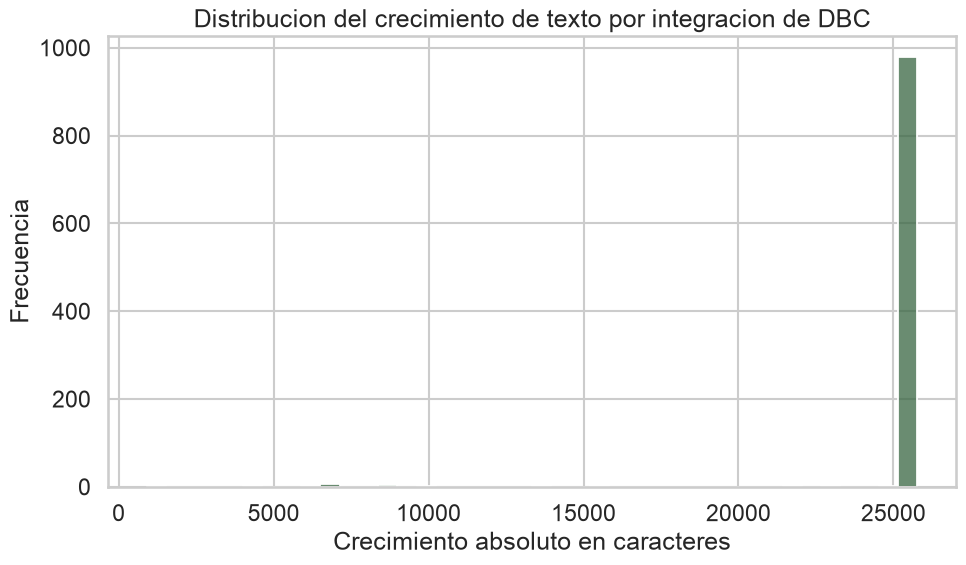

Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_enriched_growth_distribution.png


In [18]:
growth_df = analysis_df[analysis_df["has_dbc"]].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(growth_df["char_growth_abs"], bins=40, color="#386641", ax=ax)
ax.set_title("Distribucion del crecimiento de texto por integracion de DBC")
ax.set_xlabel("Crecimiento absoluto en caracteres")
ax.set_ylabel("Frecuencia")
fig.tight_layout()
growth_fig_path = FIGURES_DIR / "eda_enriched_growth_distribution.png"
fig.savefig(growth_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Figura guardada en:", growth_fig_path)


## 7. Figura: cobertura por tipo de contratacion


/tmp/ipykernel_129136/4218477123.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tipo_coverage, x="tipo_contratacion", y="cobertura_pct", palette="crest", ax=ax)


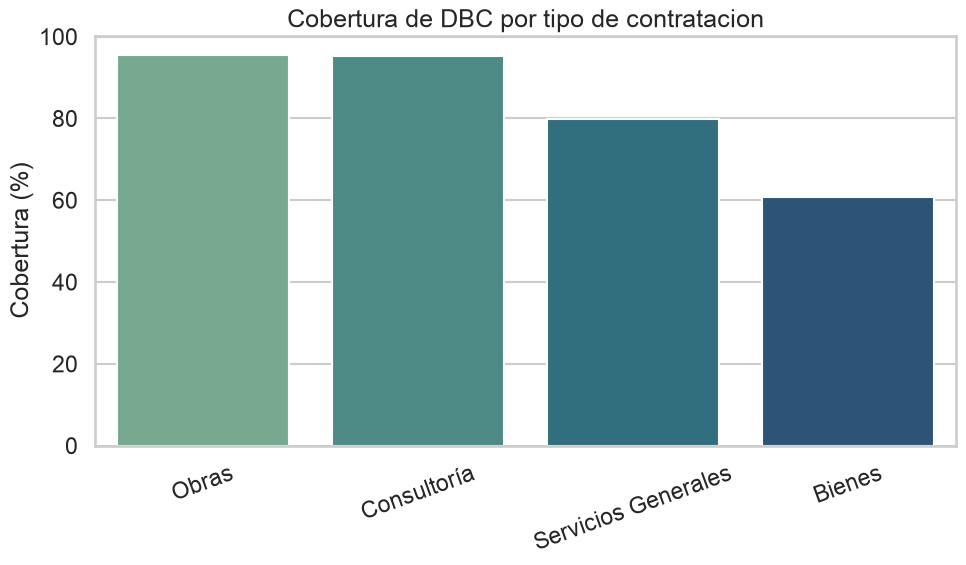

Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_enriched_coverage_by_tipo.png


,tipo_contratacion,total,con_dbc,cobertura_pct
2,Obras,200,191,95.50
1,Consultoría,105,100,95.24
3,Servicios Generales,173,138,79.77
0,Bienes,940,571,60.74


In [19]:
tipo_coverage = (
    analysis_df.groupby("tipo_contratacion", dropna=False)
    .agg(total=("cuce", "count"), con_dbc=("has_dbc", "sum"))
    .reset_index()
)
tipo_coverage["cobertura_pct"] = (tipo_coverage["con_dbc"] / tipo_coverage["total"] * 100).round(2)
tipo_coverage = tipo_coverage.sort_values("cobertura_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=tipo_coverage, x="tipo_contratacion", y="cobertura_pct", palette="crest", ax=ax)
ax.set_title("Cobertura de DBC por tipo de contratacion")
ax.set_xlabel("")
ax.set_ylabel("Cobertura (%)")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
tipo_fig_path = FIGURES_DIR / "eda_enriched_coverage_by_tipo.png"
fig.savefig(tipo_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Figura guardada en:", tipo_fig_path)
display(tipo_coverage)


## 8. Figura: cobertura por modalidad


/tmp/ipykernel_129136/3600459279.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=modalidad_coverage, x="modalidad", y="cobertura_pct", palette="viridis", ax=ax)


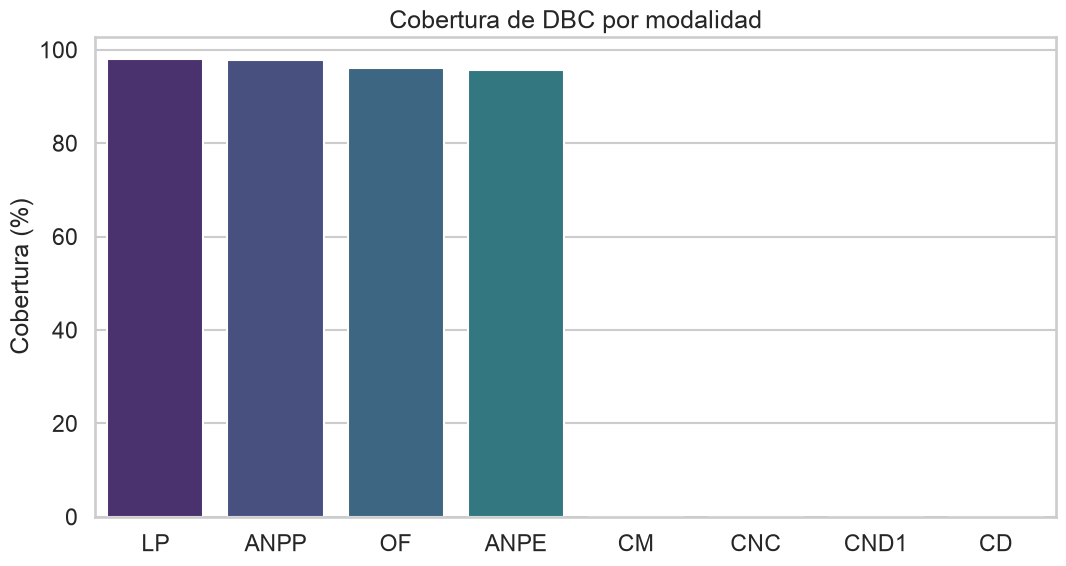

Figura guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/figures/eda_enriched_coverage_by_modalidad.png


,modalidad,total,con_dbc,cobertura_pct
6,LP,97,95,97.94
1,ANPP,447,437,97.76
7,OF,75,72,96.00
0,ANPE,414,396,95.65
3,CM,188,0,0.00
4,CNC,121,0,0.00
5,CND1,75,0,0.00
2,CD,1,0,0.00


In [20]:
modalidad_coverage = (
    analysis_df.groupby("modalidad", dropna=False)
    .agg(total=("cuce", "count"), con_dbc=("has_dbc", "sum"))
    .reset_index()
)
modalidad_coverage["cobertura_pct"] = (
    modalidad_coverage["con_dbc"] / modalidad_coverage["total"] * 100
).round(2)
modalidad_coverage = modalidad_coverage.sort_values(["cobertura_pct", "total"], ascending=[False, False])

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=modalidad_coverage, x="modalidad", y="cobertura_pct", palette="viridis", ax=ax)
ax.set_title("Cobertura de DBC por modalidad")
ax.set_xlabel("")
ax.set_ylabel("Cobertura (%)")
fig.tight_layout()
modalidad_fig_path = FIGURES_DIR / "eda_enriched_coverage_by_modalidad.png"
fig.savefig(modalidad_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print("Figura guardada en:", modalidad_fig_path)
display(modalidad_coverage)


## 9. Casos comparativos base vs enriquecido


In [21]:
examples_df = (
    analysis_df[analysis_df["has_dbc"]]
    .sort_values("char_growth_abs", ascending=False)
    [[
        "cuce",
        "entidad",
        "tipo_contratacion",
        "modalidad",
        "objeto_contratacion",
        "base_chars",
        "enriched_chars",
        "char_growth_abs",
        "word_growth_abs",
        "texto_rag",
        "texto_rag_enriched",
    ]]
    .head(10)
    .copy()
)

examples_df.to_csv(EXAMPLES_PATH, index=False, encoding="utf-8-sig")
display(examples_df[[
    "cuce",
    "tipo_contratacion",
    "modalidad",
    "base_chars",
    "enriched_chars",
    "char_growth_abs",
    "word_growth_abs",
]])
print("Tabla guardada en:", EXAMPLES_PATH)


,cuce,tipo_contratacion,modalidad,base_chars,enriched_chars,char_growth_abs,word_growth_abs
1056,26-0041-26-1668240-1-1,Consultoría,OF,686,26462,25776,3611
1339,26-0054-03-1641400-3-1,Consultoría,ANPP,655,26400,25745,3671
1063,26-0041-26-1668212-1-1,Consultoría,OF,648,26386,25738,3627
1355,26-1701-00-1665790-1-1,Bienes,LP,682,26410,25728,3722
48,26-0291-00-1669853-1-1,Consultoría,OF,605,26329,25724,3648
131,26-1435-00-1669732-1-1,Consultoría,ANPE,598,26315,25717,3692
235,26-0572-00-1669170-1-1,Servicios Generales,ANPP,589,26297,25708,3720
120,26-0015-15-1667856-1-1,Servicios Generales,ANPP,585,26289,25704,3613
247,26-0041-15-1669677-1-1,Bienes,ANPE,578,26275,25697,3664
970,26-0054-03-1668437-1-1,Consultoría,ANPP,575,26269,25694,3721


Tabla guardada en: /var/www/codigo/maestria_ia/umsa/diplomados_intermedios/dip_03/outputs/tables/enriched_text_examples.csv


## 10. Hallazgos resumidos

Usa esta celda como apoyo narrativo para la monografia. Ajusta el texto final segun los resultados concretos mostrados arriba.


In [22]:
dbc_count = int(analysis_df["has_dbc"].sum())
coverage_pct = float(analysis_df["has_dbc"].mean() * 100)
avg_base = float(analysis_df["base_chars"].mean())
avg_enriched = float(analysis_df["enriched_chars"].mean())
avg_growth = float(analysis_df["char_growth_abs"].mean())

print("Hallazgos sugeridos para redaccion:")
print(f"- El corpus enriquecido integra DBC en {dbc_count} de {len(analysis_df)} convocatorias ({coverage_pct:.2f}%).")
print(f"- La longitud media del texto pasa de {avg_base:.2f} a {avg_enriched:.2f} caracteres.")
print(f"- El crecimiento medio absoluto del contexto textual es de {avg_growth:.2f} caracteres por registro.")
print("- Las figuras exportadas pueden sustentar la justificacion metodologica del segundo experimento de retrieval/RAG.")


Hallazgos sugeridos para redaccion:
- El corpus enriquecido integra DBC en 1000 de 1418 convocatorias (70.52%).
- La longitud media del texto pasa de 422.30 a 18340.68 caracteres.
- El crecimiento medio absoluto del contexto textual es de 17918.38 caracteres por registro.
- Las figuras exportadas pueden sustentar la justificacion metodologica del segundo experimento de retrieval/RAG.
